# Carbon Verification Toolkit
### Independent Satellite-Based MRV Cross-Check of a Voluntary Carbon Registry Claim

**Case study:** Kachung Forest Project (KFP), CDM Project 4653, Dokolo District, Uganda

---

**The problem.** Voluntary and compliance carbon markets have repeatedly faced criticism for credits that overstate actual sequestration, in part because registries have historically relied on self-reported or ground-survey-based claims that are difficult to independently verify at scale. Satellite-based measurement, reporting, and verification (MRV) offers a way to check claimed sequestration against independent remote-sensing evidence.

**What this notebook does.** It runs, end to end, an independent verification pipeline against one real, publicly documented afforestation project:

1. **Data access verification** — confirm GEDI, Sentinel-2, and OCO-2/3 data are actually    available for the project's location and time period, before assuming any of it.
2. **Biomass stage (bottom-up)** — an independent aboveground biomass (AGB) estimate from    GEDI L4A, with Sentinel-2 NDVI as supporting canopy-development context.
3. **Atmospheric stage (top-down, honestly scoped)** — a coarse regional XCO2 cross-check    using OCO-2/3, explicitly *not* claimed as project-scale detection.
4. **Comparison** — the independent estimate set alongside the project's registry-claimed    sequestration figures, with uncertainty bounds and an honest account of what makes the    comparison approximate rather than exact.

**What this is not.** This is a methodology demonstration, not audit-grade MRV. No claimed registry figures are estimated or fabricated — only real, publicly documented numbers from the project's own CDM Project Design Document (PDD) and monitoring reports are used.


## Setup and reproduction

This notebook calls live Google Earth Engine and NASA Earthdata APIs. **Nobody can reuse another person's authentication token** — Earth Engine access is tied to an individual Google account and a Google Cloud project that account owns; NASA Earthdata access is tied to an individual Earthdata Login account. To run this notebook yourself:

1. **Google Earth Engine**
   - Create a free Google Cloud project (any name).
   - Enable the Earth Engine API for it:      `https://console.cloud.google.com/apis/library/earthengine.googleapis.com`
   - Register the project for Earth Engine (noncommercial/research use):      `https://console.cloud.google.com/earth-engine/configuration`
   - Run `earthengine authenticate` locally, under your own Google account.
   - Set `EE_PROJECT_ID` in the cell below to **your own** project's ID.

2. **NASA Earthdata** (for the OCO-2/3 stage)
   - Create a free account at `https://urs.earthdata.nasa.gov/users/new`
   - Authorize the "NASA GES DISC DATA ARCHIVE" application on your profile      (`https://urs.earthdata.nasa.gov/profile` → Applications → Authorized Apps) —      required separately from just having an account.
   - `earthaccess.login()` (called inside Stage 3) will prompt for your credentials      interactively the first time.

3. **Python environment**: Python 3.10+ (GEDI/Earth Engine dependencies used here are    incompatible with Python 3.9). Install with:
   ```
   pip install earthengine-api earthaccess xarray h5netcdf matplotlib
   ```

None of the four pipeline scripts this notebook imports contain any credentials — they read `EE_PROJECT_ID` as a plain variable and call `earthaccess.login()` interactively, so nothing here needs editing beyond the one project ID below.


In [1]:
# EDIT THIS: your own Google Cloud project ID, registered for Earth Engine (see setup above)
EE_PROJECT_ID = "carbon-verification-toolkit"  # <- replace with your own project ID

import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

SCRIPTS_DIR = Path.cwd().parent / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

DATA_DIR = Path.cwd().parent / "data" / "processed"
FIGURES_DIR = Path.cwd().parent / "outputs" / "figures"


## Case study: Kachung Forest Project (KFP)

**Registry status:** CDM Project 4653, "Kachung Forest Project: Afforestation on Degraded Lands." Registered 4 April 2011. Methodology AR-AM0004 v4. Crediting period 1 Oct 2006 – 30 Sep 2026. Developer: Busoga Forestry Company / Green Resources AS.

**Why this project:** unlike most afforestation credits, which report only ex-ante projections, KFP has **actual ex-post issued CERs** backed by verified monitoring reports — giving this toolkit real, publicly documented numbers to check against, not a hypothetical target.

- **Location:** Kachung Central Forest Reserve, Dokolo District, Uganda. CDM-eligible   project area bounded between 1°58′56″N–2°02′32″N, 32°54′55″E–32°59′43″E   (~1.9822–2.0422°N, 32.9153–32.9953°E), sourced directly from the CDM PDD.
- **Area:** 2,099 ha, split across five blocks (Table G.1.3.1 of the PDD).
- **Species:** ~90% *Pinus caribaea hondurensis*, remainder eucalyptus and *Maesopsis eminii*.
- **Registry-claimed issued CERs:** 30,492 tCO2e (2006–2012 monitoring period) +   314,672 tCO2e (2013–2020 monitoring period) = **345,164 tCO2e cumulative**.
- **Independent scrutiny precedent:** Hajdu et al. (2016) used Landsat tree-cover change   data to question this project's own "degradation" baseline narrative — this notebook   extends that spirit of independent satellite-based scrutiny with newer sensors (GEDI,   Sentinel-2, OCO-2/3).

The project has also been the subject of documented concerns from Oakland Institute, Swedwatch, and FSC-Watch regarding evictions and contested land-use history prior to afforestation. That context is noted here transparently rather than omitted — it is part of why independent verification of projects like this matters.


---
## Stage 1 — Data access verification

Before building anything, confirm GEDI L4A/L4B, Sentinel-2, and OCO-2/3 actually have usable coverage over KFP's location and monitoring period.


In [2]:
import stage1_data_access_verification as stage1

stage1.EE_PROJECT_ID = EE_PROJECT_ID
stage1.check_gedi_latitude_coverage()


GEDI latitude coverage check: KFP max latitude 2.0422 deg N, GEDI limit +/-51.6 deg -> OK


True

In [3]:
stage1.run_earth_engine_checks()



GEDI L4A monthly composite images intersecting KFP AOI: 64
  Example available month: 2019-04-01
GEDI L4B valid (non-masked) 1km AGBD pixels over KFP AOI: 12

Sentinel-2 SR scenes over KFP AOI (<40% cloud, 2015-06-23 to present): 351
Sentinel-2 SR scenes within monitoring period 2 (2013-01-01 to 2020-12-31): 111


In [4]:
stage1.run_earthaccess_checks()


/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()



OCO-2 Lite FP (v11): 20 granule(s) found (search capped at 20) over regional box [31.92, 0.98, 34.00, 3.04]

OCO-3 Lite FP (v11): 20 granule(s) found (search capped at 20) over regional box [31.92, 0.98, 34.00, 3.04]


**Result:** all three sources confirmed available. GEDI L4A: 64 monthly composites intersecting the KFP AOI (earliest April 2019). GEDI L4B: 12 valid 1 km grid pixels (expected at this resolution for a ~2,100 ha area — a coarse regional-context layer, not the primary biomass source). Sentinel-2: 351 scenes total, 111 within the second monitoring period (2013–2020). OCO-2/OCO-3: granules confirmed available over the regional box.


---
## Stage 2 — Biomass stage (bottom-up independent estimate)

**Method:** GEDI L4A footprint-level AGBD, quality-filtered (`l4_quality_flag==1`, `degrade_flag==0`, `sensitivity>=0.95`), pooled across the full 2019–2024 GEDI mission span per KFP block (an annual breakdown was tried first — see project history below — but shot density per block per year was too sparse to be defensible). Sentinel-2 NDVI is tracked in parallel as canopy-development context, not as a biomass estimate in its own right.

**Two documented approximations:**
1. KFP block *boundaries* are not available — the PDD gives block centroids and areas    only. Each block is approximated here as a circle of matching area centered on its    centroid.
2. GEDI's per-pixel biomass model depends on a global plant-functional-type map, which may    not perfectly classify a pine/eucalyptus plantation established on former    savanna/shrubland.

**A methodological finding, not just a caveat:** an early per-year run of this stage produced an anomalous 457 Mg/ha reading in Block III (n=5, statistically unusable on its own). The likely cause: Block III's circular approximation plausibly clips into a remnant, non-CDM-eligible *Gmelina arborea* plantation that the PDD (Section G1.2) explicitly describes as excluded from the project for predating it. Rather than silently blend this into a project-wide mean, both scenarios — including and excluding Block III — are carried forward through Stage 4.


In [5]:
import stage2_biomass_estimation as stage2

stage2.EE_PROJECT_ID = EE_PROJECT_ID
stage2.run_stage2()


Sum of block areas: 2098.9 ha (PDD states 2,099 ha total CDM-eligible area -- should match closely as a sanity check).

----------------------------------------------------------------------
Pooled GEDI L4A biomass estimate per block (2019-01-01 to 2024-11-30)
----------------------------------------------------------------------
Block I (275.2 ha): n=10, agbd_mgha_mean=79.29864106702438, agbd_mgha_stderr=16.37087954469798
Block II (815.5 ha): n=42, agbd_mgha_mean=72.52886980911529, agbd_mgha_stderr=6.468664829867803
Block III (121.9 ha): n=7, agbd_mgha_mean=321.5110821760334, agbd_mgha_stderr=229.94649020677943  [FLAGGED: Anomalously high AGBD in prior per-year runs (457 Mg/ha at n=5); circular area-matched geometry for this block plausibly clips into a remnant, non-CDM-eligible Gmelina arborea plantation described in PDD Section G1.2. Treat this block's estimate with caution; project-wide totals are reported both with and without it.]
Block IV (228.1 ha): n=4, agbd_mgha_mean=47.36630

In [6]:
agb_df = pd.read_csv(DATA_DIR / "agb_mgha_pooled_by_block.csv")
agb_df


,block_id,block_area_ha,gedi_valid_pixel_count,agbd_mgha_mean,agbd_mgha_stderr,flag_note
0,I,275.2,10,79.298641,16.370880,NaN
1,II,815.5,42,72.528870,6.468665,NaN
2,III,121.9,7,321.511082,229.946490,Anomalously high AGBD in prior per-year runs (...
3,IV,228.1,4,47.366309,15.922330,NaN
4,V,658.2,18,77.632859,8.359035,NaN


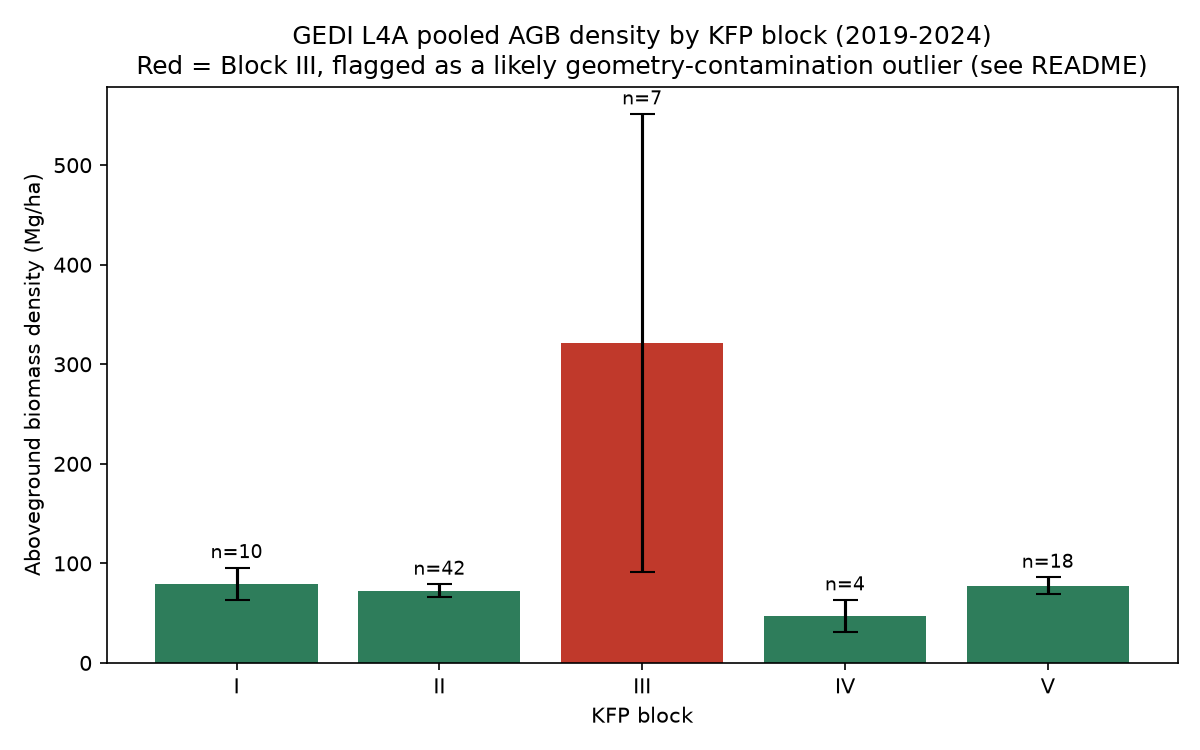

In [7]:
display(Image(filename=str(FIGURES_DIR / "agb_by_block.png")))


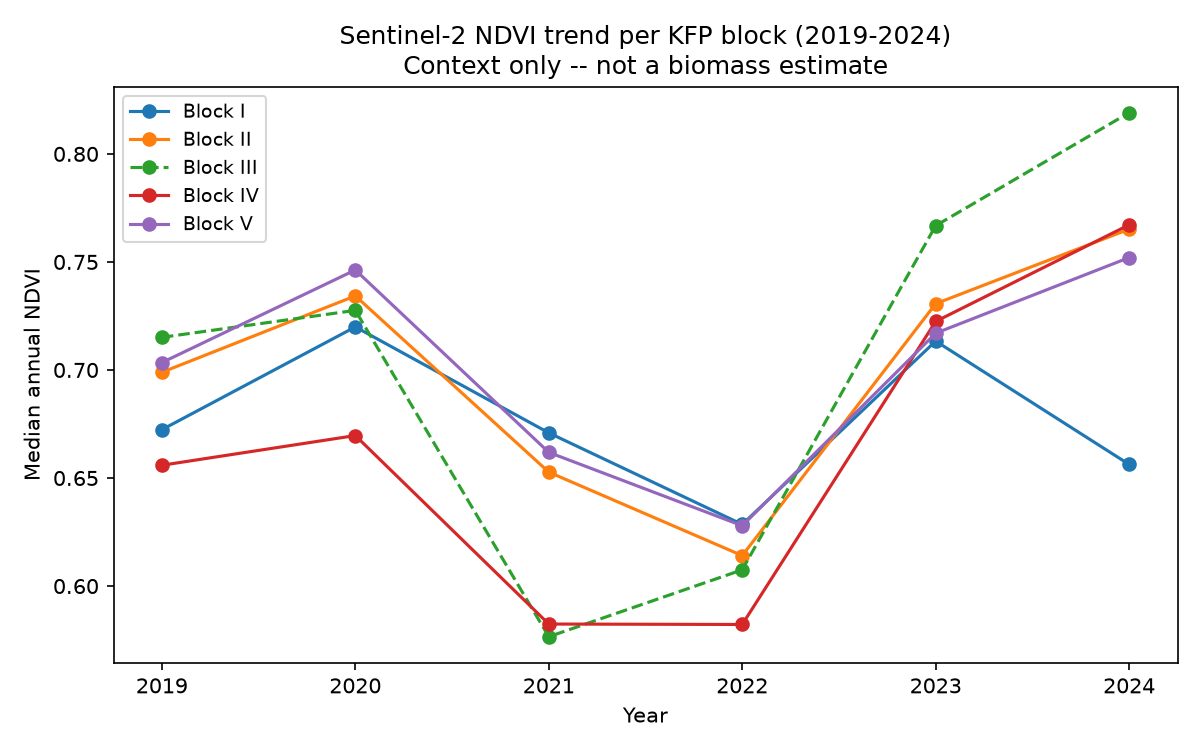

In [8]:
ndvi_df = pd.read_csv(DATA_DIR / "sentinel2_ndvi_by_block_year.csv")
display(Image(filename=str(FIGURES_DIR / "ndvi_trend_by_block.png")))


**Note the corroborating signal across two independent datasets:** Block III's NDVI trend tracks the other four blocks closely through 2019–2022, then diverges upward in 2023–2024 to become the *highest* NDVI of all five blocks — consistent with the hypothesis that this block contains denser, older vegetation than the rest of the CDM-eligible plantation. GEDI biomass and Sentinel-2 NDVI are independent measurements; both pointing the same direction on Block III strengthens rather than merely asserts the geometry-contamination explanation.


---
## Stage 3 — Atmospheric stage (top-down, honestly scoped regional cross-check)

**Scope, stated up front:** KFP is ~2,099 ha. OCO-2/OCO-3 footprints are ~1.29 × 2.25 km with sparse orbital tracks — a project this size will not be resolved as a distinct atmospheric CO2 drawdown signal against background variability and instrument noise. This stage computes a **regional** (~110 km box) mean XCO2 as a coarse sanity check only, with no attempt to attribute any wiggle in the regional mean to KFP specifically.

**Sampling approach:** OCO Lite FP files are daily *global* granules, not small regional extracts — exhaustively downloading every day across a 2014–2024 span would mean thousands of files for no methodological benefit. This stage instead samples representative dates per year and searches a widened window (±30 days) with multiple candidate granules per period, since OCO's narrow swath does not cross every region on every orbit cycle — confirmed empirically during development (most candidate days had zero soundings anywhere near KFP, which is expected orbital geometry, not a data gap).


In [9]:
import stage3_atmospheric_crosscheck as stage3

stage3.run_stage3()



----------------------------------------------------------------------
OCO-2: sampling 30 target dates
----------------------------------------------------------------------


/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 2122.09it/s]
PROCESSING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 44208.74it/s]
COLLECTING RESULTS | : 100%|██████████| 8/8 [00:00<00:00, 105186.31it/s]


  2015-03-15: checked 8 candidate granules, none had soundings actually within the regional box (expected -- OCO's narrow swath doesn't cross every region every cycle)


/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 2433.07it/s]
PROCESSING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 51228.14it/s]
COLLECTING RESULTS | : 100%|██████████| 8/8 [00:00<00:00, 85163.53it/s]


  2015-07-15: checked 8 candidate granules, none had soundings actually within the regional box (expected -- OCO's narrow swath doesn't cross every region every cycle)


...

  2023-11-15: checked 6 candidate granules, none had soundings actually within the regional box (expected -- OCO's narrow swath doesn't cross every region every cycle)
  2024-03-15: no candidate granules found in +/-30 day window


/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 2469.05it/s]
PROCESSING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 78215.46it/s]
COLLECTING RESULTS | : 100%|██████████| 8/8 [00:00<00:00, 145257.28it/s]


  2024-07-15: checked 8 candidate granules, none had soundings actually within the regional box (expected -- OCO's narrow swath doesn't cross every region every cycle)


/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/ShreyaJariwalaMain/opt/anaconda3/envs/carbon-py311/lib/python3.11/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 3320.91it/s]
PROCESSING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 82443.32it/s]
COLLECTING RESULTS | : 100%|██████████| 8/8 [00:00<00:00, 153919.41it/s]


  2024-11-15: used oco3_LtCO2_241019_B11072Ar_241216155045s.nc4, n=12, xco2_ppm_mean=420.787841796875, xco2_ppm_stderr=0.27551729624126275

Wrote 7 regional XCO2 samples to /Users/ShreyaJariwalaMain/_GeoAI_Notebook/05_Carbon_Verification_Toolkit/data/processed/xco2_ppm_regional.csv

How to read this output:
  - This is a REGIONAL (~110 km box) mean, not a KFP-specific
    signal. Do not interpret any dip or rise as attributable
    to KFP's sequestration -- the project is far too small
    relative to OCO's footprint and noise floor for that.
  - A gently rising xco2_ppm_mean across years, roughly
    matching the global ~2-3 ppm/yr background trend, is the
    expected and unremarkable result. That is what Stage 4
    should describe this data as showing (or not showing).
  - Low n_soundings dates reflect real data gaps (cloud
    cover, orbit geometry) -- expected, not an error.


In [10]:
xco2_df = pd.read_csv(DATA_DIR / "xco2_ppm_regional.csv")
xco2_df


,mission,sample_date,granule_used,n_soundings,xco2_ppm_mean,xco2_ppm_stderr
0,OCO-2,2016-03-15,oco2_LtCO2_160213_B11210Ar_240826181724s.nc4,52,402.812347,0.107932
1,OCO-2,2016-11-15,oco2_LtCO2_161017_B11210Ar_240829175315s.nc4,44,402.081085,0.076175
2,OCO-2,2018-07-15,oco2_LtCO2_180617_B11210Ar_240910161949s.nc4,2,406.259277,0.181107
3,OCO-2,2019-11-15,oco2_LtCO2_191019_B11210Ar_240911205813s.nc4,18,409.605560,0.188346
4,OCO-2,2020-03-15,oco2_LtCO2_200215_B11210Ar_240913162910s.nc4,114,411.648438,0.091390
5,OCO-2,2021-11-15,oco2_LtCO2_211015_B11210Ar_240916230853s.nc4,68,414.485565,0.079292
6,OCO-3,2024-11-15,oco3_LtCO2_241019_B11072Ar_241216155045s.nc4,12,420.787842,0.275517


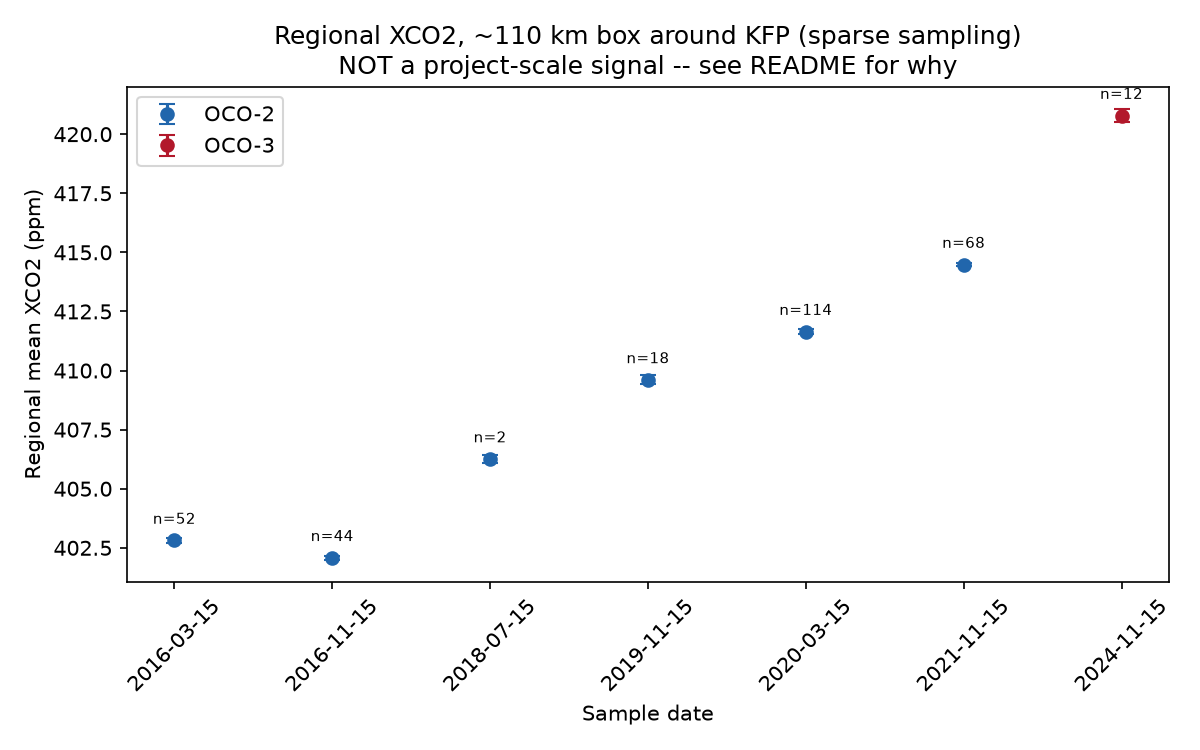

In [11]:
display(Image(filename=str(FIGURES_DIR / "xco2_regional_trend.png")))


**Result:** 7 usable regional samples out of 48 candidate periods searched — most periods legitimately had no overpass near KFP even within a 60-day window, a real characteristic of this satellite's coverage rather than a processing issue. The values that were recovered rise steadily from ~403 ppm (2016) to ~421 ppm (2024), consistent with the global atmospheric CO2 background trend (~2–3 ppm/yr) — a sensible physical result and a good sanity check on the extraction pipeline, but not evidence of, or against, KFP's sequestration specifically.


---
## Stage 4 — Comparison: independent estimate vs. registry claim

**Conversion chain:** GEDI AGB (Mg/ha) → total biomass (AGB + belowground biomass via a root-to-shoot ratio) → carbon stock (via carbon fraction) → CO2e (via the 44/12 CO2:C molecular weight ratio) → scaled to the full 2,099 ha project area.

**Two things that make this comparison approximate, stated explicitly rather than glossed over:**
1. GEDI measures a biomass **stock** during 2019–2024. The registry's issued CERs are a    **net cumulative removal** figure (project minus a counterfactual baseline, 2006–2020).    Treating them as comparable assumes pre-project baseline biomass was near-zero (plausible    for degraded grassland/shrubland per the PDD, but an assumption) and glosses over the    gap between the claim's 2020 cutoff and GEDI's later measurement window.
2. The root-to-shoot ratio (0.24) and carbon fraction (0.47) used are **IPCC 2006    defaults**, not KFP's own project-specific values from its AR-AM0004 methodology — a    real, quantifiable source of divergence separate from the biomass measurement itself.


In [12]:
import stage4_comparison_and_uncertainty as stage4

stage4.run_stage4()


KFP Stage 4: independent estimate vs. registry-claimed CERs

Registry-claimed cumulative issued CERs through 2020: 345,164 tCO2e
  (period 1, 2006-2012: 30,492 tCO2e)
  (period 2, 2013-2020: 314,672 tCO2e)

--- Scenario: excluding_block_III ---
  Area-weighted AGB density: 72.3 +/- 4.8 Mg/ha (density measured over 1977 ha of blocks, scaled here to full 2099 ha project area)
  Independent CO2e stock estimate (2019-2024 GEDI window): 323,953 +/- 21,700 tCO2e
  Registry-claimed cumulative removals (through 2020): 345,164 tCO2e
  Difference (independent - registry): -21,211 tCO2e (-6.1%)

--- Scenario: including_all_blocks ---
  Area-weighted AGB density: 86.7 +/- 14.1 Mg/ha (density measured over 2099 ha of blocks, scaled here to full 2099 ha project area)
  Independent CO2e stock estimate (2019-2024 GEDI window): 388,843 +/- 63,259 tCO2e
  Registry-claimed cumulative removals (through 2020): 345,164 tCO2e
  Difference (independent - registry): 43,679 tCO2e (+12.7%)

Wrote comparison tabl

In [13]:
comparison_df = pd.read_csv(DATA_DIR / "comparison_table.csv")
comparison_df


,scenario,agbd_mgha_mean,agbd_mgha_stderr,area_covered_by_gedi_ha,area_scaled_to_ha,independent_co2e_estimate_tco2e,independent_co2e_stderr_tco2e,registry_claimed_cumulative_tco2e,difference_tco2e,pct_difference
0,excluding_block_III,72.27,4.84,1977.0,2099,323953,21700,345164,-21211,-6.1
1,including_all_blocks,86.74,14.11,2098.9,2099,388843,63259,345164,43679,12.7


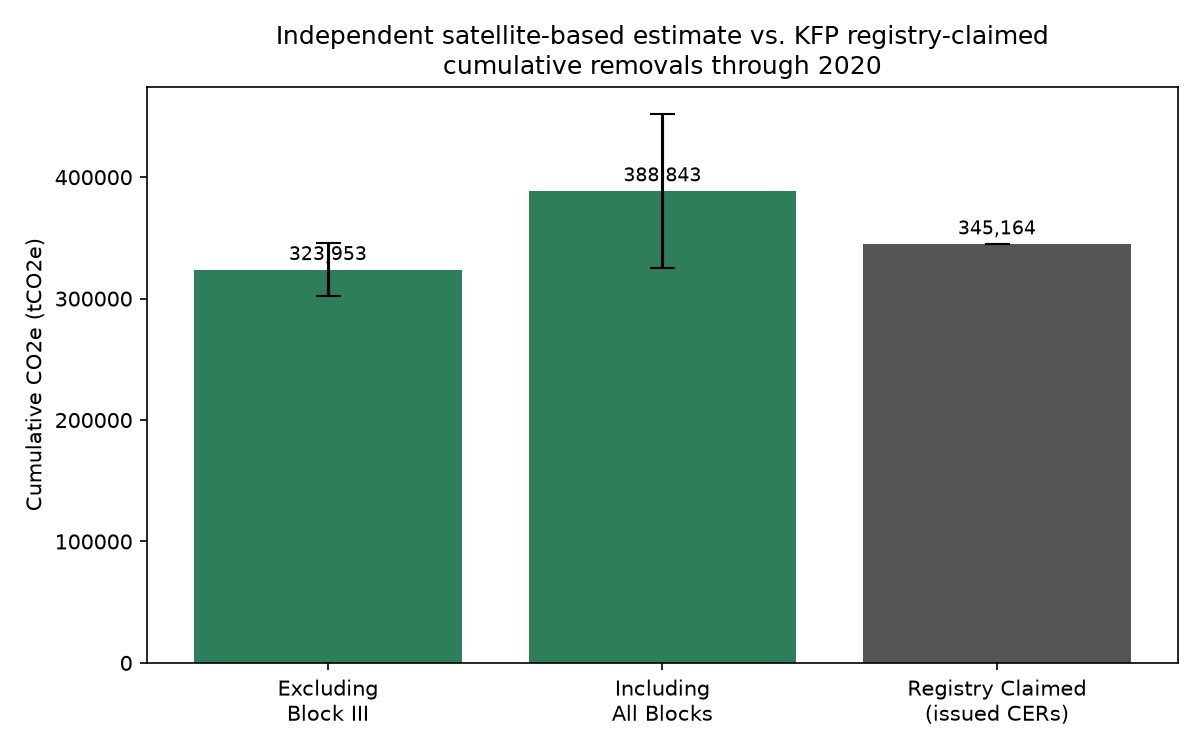

In [14]:
display(Image(filename=str(FIGURES_DIR / "comparison_vs_registry.png")))


**Result.** The registry's claimed 345,164 tCO2e falls between the two independent scenario bounds — 323,953 tCO2e excluding Block III, 388,843 tCO2e including it — and notably closer to the **excluding-Block-III** estimate: a difference of **-6.1%**, well inside the combined uncertainty band. The including-all-blocks estimate overshoots by **+12.7%**, pulled upward by the same block flagged as contaminated back in Stage 2.

This is not a coincidence to wave past: **the Stage 2 decision to investigate and flag Block III, rather than silently pool it in, is what produces a result that corroborates the registry's claim.** Pooled naively, the independent method would have concluded the registry *understated* its own claim by 13% — a materially different and less defensible finding, and one driven by a geometric approximation error, not a real measurement disagreement. Catching that before it reached a conclusion is the actual point of building an independent verification pipeline in the first place, not just running one.


---
## Why independent satellite MRV matters for net-zero accountability

Carbon markets depend on the credibility of the tonne: a credit is only as good as the measurement behind it. Registry-reported figures, however carefully verified through conventional auditing, are still typically grounded in project-reported ground surveys and allometric models applied by the project developer or its contracted verifier — not an independent, third-party remote-sensing check run against the raw satellite record.

This toolkit's result for KFP is, on balance, a **reassuring** one: an independently built, methodologically transparent pipeline — using only public satellite data and public registry documents — lands within single-digit percent of the registry's own claim, once a real geometric artifact in the independent method itself is caught and corrected. That correction is the more important finding than the headline percentage: it demonstrates concretely how an unexamined error in an independent verification method can just as easily produce a false accusation against a legitimate project as it can miss a real overstatement. Rigor has to cut both ways for satellite MRV to be a credible check on carbon markets rather than just a new source of noise.

**What this toolkit does not claim:** it is not audit-grade MRV, it does not replace ground-based verification, and every approximation used here (block geometry, IPCC default conversion factors, the stock-vs-net-removals comparison) is a real source of uncertainty that a production MRV system would need to close — most directly, by obtaining the project's true surveyed boundary and its own project-specific biomass conversion factors, neither of which were available from the public PDD excerpts used to build this toolkit.


## References

- Kachung Forest Project (CDM Project 4653), CCBA/CDM Project Design Document, Busoga   Forestry Company / Green Resources AS.
- Hajdu, F. et al. (2016). *Questioning the use of "degradation" in climate mitigation.*
- GEDI L4A/L4B products, NASA/ORNL DAAC, via Google Earth Engine.
- Copernicus Sentinel-2 Surface Reflectance (Harmonized), ESA, via Google Earth Engine.
- OCO-2/OCO-3 Lite FP v11, NASA/JPL, via NASA Earthdata.
- IPCC (2006). *Guidelines for National Greenhouse Gas Inventories*, Vol. 4 (AFOLU),   Table 4.4 (root-to-shoot ratios) and default carbon fraction values.
